#### Import packages

In [31]:
import os
import pyproj
import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd
import csv
from rasterio.windows import from_bounds
from rasterio.mask import mask
from datetime import datetime 

Define Functions

In [32]:
def check_path(x):
    if os.path.exists(x):
        print("The file exists")
    else:
        print("The file does not exist")

Read in Vector Layer

In [33]:
vector_path = r"C:\Users\Carol\Dropbox\GIS\Projects\IOB_AlbertineRift\2_intermediate_data\AlbertineRift_data.gpkg" #rfo_mining_aoi"
check_path(vector_path)

# vector_path = r"path/to/vector_file.shp"  # Replace with the actual path to your vector file
layer_name = "AlbertineRift_aoi_utm35s"

The file exists


In [34]:
# Read the vector features
vector_features = gpd.read_file(vector_path, layer=layer_name)
vector_features = vector_features.to_crs(epsg=4326)
print(vector_features.head())

                          nom_ap                    province        aoi_name  \
0    Parc National de la Virunga                   Nord Kivu     PNVi_Area_A   
1  Parc National du Kahuzi-Biega  Nord-Kivu/Sud-Kivu/Maniema   PNKB_Highland   
2  Parc National du Kahuzi-Biega  Nord-Kivu/Sud-Kivu/Maniema  PNKB_Northeast   

     area_km2                                           geometry  
0  108.653017  MULTIPOLYGON (((29.33499 -1.49185, 29.33425 -1...  
1  206.702434  MULTIPOLYGON (((28.76819 -2.25532, 28.65840 -2...  
2  303.266793  MULTIPOLYGON (((28.75571 -2.30740, 28.64778 -2...  


In [35]:
# Select 2 of the 3 AOI features by aoi_name
selected_aoi_names = ['PNVi_Area_A', 'PNKB_Highland']  # Replace with the actual AOI names you want to select
vector_features = vector_features[vector_features['aoi_name'].isin(selected_aoi_names)]

In [36]:
vector_features.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [37]:
# bbox = vector_features.to_crs(32735).total_bounds
bbox = vector_features.total_bounds
print(bbox)

[28.65839976 -2.25532393 29.34862983 -1.45587661]


In [38]:
# Set the PROJ_LIB environment variable
proj_lib_path = r'C:\ProgramData\miniconda3\envs\rasterio\Lib\site-packages\pyproj'
os.environ['PROJ_LIB'] = proj_lib_path

# Set the PROJ data directory using pyproj
pyproj.datadir.set_data_dir(proj_lib_path)

# Verify the PROJ data directory
print(f"PROJ data directory: {pyproj.datadir.get_data_dir()}")

PROJ data directory: C:\ProgramData\miniconda3\envs\rasterio\Library\share\proj


In [9]:
# Define the bounding box coordinates (min_lon, min_lat, max_lon, max_lat)
# bbox = (27.9859718673429, 1.30005834822025, 28.0433044433594, 1.34207344055176)
# bbox = (28.756724591121483, -2.158958820093456, 28.82484395979548, -2.088120619158876)
bbox = (28.65839976, -2.25532393, 29.34862983, -1.45587661)

In [10]:
# Open the raster file
raster_path =r"C:\Users\Carol\Dropbox\GIS\Projects\IOB_AlbertineRift\1_raw_data\raster\gfw_alerts\20250529\00N_020E.tif"
# raster_path =r"C:\Users\Carol\Dropbox\GIS\Projects\IOB_AlbertineRift\2_intermediate_data\gfw_alerts\20250227\00N_020E_clipped_optimized.tif"
check_path(raster_path)

The file exists


In [11]:
# Open the raster file and read in the data
with rasterio.open(raster_path) as src:
    
    # Get the bounds of the bounding box
    # bbox = src.bounds

    # Get the bounds of the bounding box
    window = from_bounds(bbox[0], bbox[1], bbox[2], bbox[3], src.transform)
    
    # Read raster within this window
    data = src.read(1, window=window)

print(f"Raster data shape:", bbox)
print(f"Raster data window:", window)
print(f"Raster data shape:", data.shape)

Raster data shape: (28.65839976, -2.25532393, 29.34862983, -1.45587661)
Raster data window: Window(col_off=86583.9976, row_off=14558.7661, width=6902.300700000022, height=7994.473199999997)
Raster data shape: (7994, 6902)


# DO NOT RUN THE FOLLOWNIG CELL - IT IS A MESS!

In [ ]:
import rasterio
from rasterio.io import MemoryFile
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_bounds
from rasterio.windows import from_bounds

# Define the target CRS
src_crs = "EPSG:4326"   # Source coordinate system
dst_crs = "EPSG:32735"  # Target coordinate system (UTM Zone 35S)

# Define the output file path
# output_file = r"C:\Users\Carol\Dropbox\GIS\Projects\IOB_AlbertineRift\2_intermediate_data\raster\00N_020E_20250227.tif"

# Define the bounding box (in source CRS)
# bbox = [28.65839976, -2.25532393, 29.34862983, -1.45587661]  # Replace with actual bounding box coordinates

# Open the source raster file
with rasterio.open(raster_path) as src:
    
    # Ensure the source raster is in the expected CRS
    assert src.crs.to_string() == src_crs, "Source raster is not in EPSG:4326!" #CRS does not match expected CRS"

    # define window using the bounding box
    # window = from_bounds(*bbox, transform=src.transform) #src.transform)
    window = from_bounds(bbox[0], bbox[1], bbox[2], bbox[3], src.transform)
    # window = from_bounds(*dst_bbox, transform=dst_transform) #src.transform)

    # Read the data within the window
    data = src.read(window=window)

    # Extract transform for cropped window
    transform = src.window_transform(window)

    # Calculate the transform and dimensions for the reprojected raster
    dst_transform, width, height = calculate_default_transform(
        src.crs, dst_crs, data.shape[2], data.shape[1], *transform_bounds(src.crs, dst_crs, *bbox))
        # src.crs, dst_crs, src.width, src.height, *src.bounds) #bbox) # *src.bounds)

    # transform the bounding box to the target CRS
    # dst_bbox = transform_bounds(src_crs, dst_crs,*bbox)
    # dst_bbox = calculate_default_transform(src.crs, dst_crs, width, height, *bbox)[0]

    # # Calculate the transform and dimensions for the reprojected raster
    # dst_transform, width, height = calculate_default_transform(
    #     src.crs, dst_crs, window.width, window.height, *bbox) # *src.bounds)

    # # define window using the bounding box
    # # window = from_bounds(bbox[0], bbox[1], bbox[2], bbox[3], src.transform)
    # window = from_bounds(*bbox, transform=src.transform)

    # # Read the data within the window
    # data = src.read(window=window)

    # # Extract transform for cropped window
    # transform = src.window_transform(window)

    # # Calculate the transform and dimensions for the reprojected raster
    # dst_transform, width, height = calculate_default_transform(
    #     src.crs, dst_crs, window.width, window.height, *bbox) # *src.bounds)
    
    # Define the metadata for the destination raster
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': dst_transform,
        'width': width,
        'height': height
    })

    # Reproject the raster data into an in-memory file
    # with MemoryFile() as memfile:
    #     with memfile.open(**kwargs) as dst:
    with rasterio.open(output_file, "w", **kwargs) as dst:
        # dst.write(reprojected_data, 1)
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest)
    
    # with memfile.open() as reprojected_src:
    #     reprojected_data = reprojected_src.read(1)
with rasterio.open(output_file) as reprojected_src:
    reprojected_data = reprojected_src.read(1)
    print(f"Reprojected raster shape: {reprojected_data.shape}")


    #     # Now you can use the reprojected raster in memory
    #     with memfile.open() as reprojected_src:
    #         # Perform your analysis here using reprojected_src
    #         data = reprojected_src.read(1)
    #         print(f"Reprojected raster data shape: {data.shape}")

# Restart Here

In [13]:
# Initialize a variable to hold the latest date
latest_date = np.datetime64('2014-12-31')

In [14]:
data.shape

(7994, 6902)

### The following takes ~2 minutes

In [15]:
# Loop over each pixel in the data array
for y in range(data.shape[0]):
    for x in range(data.shape[1]):
        # Get the alert value from the data array
        alert = data[y, x]
        
        # If the alert value is 0, skip to the next pixel
        if alert == 0:
            continue

        # Determine the confidence level and number of days since Dec 31, 2014
        conf = int(str(alert)[0])
        
        # Only process alert levels 3 or 4
        if conf not in [2, 3, 4]:
            continue
        
        # Determine the number of days since Dec 31, 2014
        days = int(str(alert)[1:])
        date = np.datetime64('2014-12-31') + np.timedelta64(days, 'D')
        
        # Update the latest date if the current date is more recent
        if date > latest_date:
            latest_date = date

In [16]:
# print(f"The latest date in the raster file is: {latest_date}")
print(f"The latest date for alert levels 2, 3, or 4 in the raster file is: {latest_date}")

The latest date for alert levels 2, 3, or 4 in the raster file is: 2025-05-19


Select which of the AOI features to use for the deforestation alert trend analysis

In [17]:
# Open the raster file
with rasterio.open(raster_path) as src:
    # Initialize a variable to hold the total deforestation area
    total_deforestation_area = 0
    
    # Loop over each vector feature
    for feature in vector_features.iterrows():
        geom = [feature[1]['geometry']]
        
        # Mask the raster data with the current vector feature
        out_image, out_transform = mask(src, geom, crop=True)
        
        # Get the data array from the masked raster
        data = out_image[0]
        
        # Calculate the deforestation area (10m x 10m pixels)
        deforestation_area = np.sum(data > 0) * 11.1 * 11.1  # Sum of non-zero pixels times pixel area
        
        
        # Add the deforestation area to the total
        total_deforestation_area += deforestation_area

print(f"Total deforestation area within the vector features: {total_deforestation_area} square meters")
print(f"Total deforestation area within the vector features: {total_deforestation_area/1_000_000} square kilometers")

Total deforestation area within the vector features: 35595492.21 square meters
Total deforestation area within the vector features: 35.59549221 square kilometers


#### Total Deforestation per AOI

In [18]:
# Open the raster file and read in the data within the bbox
with rasterio.open(raster_path) as src:
    # Create a window from the bbox
    window = from_bounds(*bbox, transform=src.transform)
    data = src.read(1, window=window)

    # Extract raster pixel size (assumes square pixels)
    pixel_size = src.res[0] * src.res[1]

    # Initialize a dictionary to hold the deforestation area for each AOI
    deforestation_by_aoi = {}

    # Loop over each vector feature
    for idx, feature in vector_features.iterrows():
        geom = [feature['geometry']]
        aoi_name = feature['aoi_name']  # Replace with the actual field name for AOI name
        
        # Mask the raster data with the current vector feature
        out_image, out_transform = mask(src, geom, crop=True)
        
        # Get the data array from the masked raster
        data = out_image[0]
        
        # Initialize a variable to hold the deforestation area for the current AOI
        deforestation_area_sqm = 0

        # Loop over each pixel in the data array
        for y in range(data.shape[0]):
            for x in range(data.shape[1]):
                # Get the alert value from the data array
                alert = data[y, x]
                
                # If the alert value is 0, skip to the next pixel
                if alert == 0:
                    continue

                # Determine the confidence level
                conf = int(str(alert)[0])
                
                # Only process alert levels 3 or 4
                if conf not in [2, 3, 4]:
                # if conf not in [4]:
                    continue
                
                # Calculate the deforestation area (10m x 10m pixels)
                deforestation_area_sqm += 11.1 * 11.1 #pixel_size  # Pixel area in square meters
        
        # Calculate the deforestation area (10m x 10m pixels)
        # deforestation_area_sqm = np.sum(data > 0) * 10 * 10  # Sum of non-zero pixels times pixel area

         # Convert to hectares and square kilometers
        deforestation_area_ha = deforestation_area_sqm / 10_000  # 1 hectare = 10,000 square meters
        deforestation_area_sqkm = deforestation_area_sqm / 1_000_000  # 1 square kilometer = 1,000,000 square meters
        
        # Add the deforestation area to the dictionary
        if aoi_name in deforestation_by_aoi:
            deforestation_by_aoi[aoi_name]['sqm'] += deforestation_area
            deforestation_by_aoi[aoi_name]['ha'] += deforestation_area_ha
            deforestation_by_aoi[aoi_name]['sqkm'] += deforestation_area_sqkm
        else:
            deforestation_by_aoi[aoi_name] = {
                'sqm': deforestation_area_sqm,
                'ha': deforestation_area_ha,
                'sqkm': deforestation_area_sqkm
            }

# Print the deforestation area for each AOI
for aoi_name, areas in deforestation_by_aoi.items():
    print(f"Total deforestation area in {aoi_name}:")
    print(f"  {areas['sqm']} square meters")
    print(f"  {areas['ha']} hectares")
    print(f"  {areas['sqkm']} square kilometers")

Total deforestation area in PNVi_Area_A:
  6845670.809998128 square meters
  684.5670809998128 hectares
  6.845670809998127 square kilometers
Total deforestation area in PNKB_Highland:
  28749821.40014541 square meters
  2874.982140014541 hectares
  28.74982140014541 square kilometers


In [19]:
pixel_size

1e-08

Read GFW Alerts into data frames defined by an AOI vector

In [20]:
# Open the raster file and read in the data within the bbox
with rasterio.open(raster_path) as src:
    # Create a window from the bbox
    window = from_bounds(*bbox, transform=src.transform)
    data = src.read(1, window=window)

    # Initialize a dictionary to hold the deforestation data by AOI and month
    deforestation_by_aoi_month = {}

    # Loop over each vector feature
    for idx, feature in vector_features.iterrows():
        geom = [feature['geometry']]
        aoi_name = feature['aoi_name']  # Replace with the actual field name for AOI name
        
        # Mask the raster data with the current vector feature
        out_image, out_transform = mask(src, geom, crop=True)
        
        # Get the data array from the masked raster
        data = out_image[0]

        # Loop over each pixel in the data array
        for y in range(data.shape[0]):
            for x in range(data.shape[1]):
                # Get the alert value from the data array
                alert = data[y, x]
                
                # If the alert value is 0, skip to the next pixel
                if alert == 0:
                    continue

                # Determine the confidence level and number of days since Dec 31, 2014
                conf = int(str(alert)[0])
                
                # Only process alert levels 3 or 4
                if conf not in [3, 4]:
                    continue
                
                days = int(str(alert)[1:])
                date = datetime(2014, 12, 31) + pd.Timedelta(days=days)
                month = date.strftime('%Y-%m')

                # Calculate the deforestation area (10m x 10m pixels)
                deforestation_area_sqm = 11.1 * 11.1  # Pixel area in square meters

                # Add the deforestation area to the dictionary
                if aoi_name not in deforestation_by_aoi_month:
                    deforestation_by_aoi_month[aoi_name] = {}
                if month not in deforestation_by_aoi_month[aoi_name]:
                    deforestation_by_aoi_month[aoi_name][month] = 0
                deforestation_by_aoi_month[aoi_name][month] += deforestation_area_sqm

# Convert the dictionary to a DataFrame
data = []
for aoi_name, months in deforestation_by_aoi_month.items():
    for month, area_sqm in months.items():
        area_ha = area_sqm / 10_000  # Convert to hectares
        area_sqkm = area_sqm / 1_000_000  # Convert to square kilometers
        data.append([aoi_name, month, area_sqm, area_ha, area_sqkm])

df = pd.DataFrame(data, columns=['AOI_Name', 'Month', 'Deforestation_SQM', 'Deforestation_HA', 'Deforestation_SQKM'])

# Sort the DataFrame by AOI_Name and Month
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values(by=['AOI_Name', 'Month'])

# Calculate cumulative deforestation
df['Cumulative_HA'] = df.groupby('AOI_Name')['Deforestation_HA'].cumsum()
df['Cumulative_SQKM'] = df.groupby('AOI_Name')['Deforestation_SQKM'].cumsum()

# Split the DataFrame into two separate DataFrames based on AOI geometry
aoi_names = df['AOI_Name'].unique()
# df_aoi1 = df[df['AOI_Name'] == aoi_names[0]].reset_index(drop=True)
df_aoi_pnkb = df[df['AOI_Name'] == aoi_names[0]].reset_index(drop=True)
df_aoi_pnvi = df[df['AOI_Name'] == aoi_names[1]].reset_index(drop=True)

# Print the DataFrames
print("DataFrame for AOI (Kahuzi-Biega):")
print(df_aoi_pnkb)
print("\nDataFrame for AOI (Virunga):")
print(df_aoi_pnvi)

DataFrame for AOI (Kahuzi-Biega):
         AOI_Name      Month  Deforestation_SQM  Deforestation_HA  \
0   PNKB_Highland 2019-01-01           11704.95          1.170495   
1   PNKB_Highland 2019-02-01           90436.14          9.043614   
2   PNKB_Highland 2019-03-01           78854.40          7.885440   
3   PNKB_Highland 2019-04-01           42384.24          4.238424   
4   PNKB_Highland 2019-05-01          115447.77         11.544777   
..            ...        ...                ...               ...   
72  PNKB_Highland 2025-01-01          311228.46         31.122846   
73  PNKB_Highland 2025-02-01          434561.67         43.456167   
74  PNKB_Highland 2025-03-01          130725.81         13.072581   
75  PNKB_Highland 2025-04-01           56183.76          5.618376   
76  PNKB_Highland 2025-05-01           20699.28          2.069928   

    Deforestation_SQKM  Cumulative_HA  Cumulative_SQKM  
0             0.011705       1.170495         0.011705  
1             0.090436 

In [21]:
output_path = r"C:\Users\Carol\Dropbox\GIS\Projects\IOB_AlbertineRift\2_intermediate_data\table"

In [22]:
df_aoi_pnkb#.head()
df_aoi_pnkb.to_csv(os.path.join(output_path, 'gfw_df_aoi_monthly_pnkb_202505.csv'), index=False)

In [23]:
df_aoi_pnvi#.head()
df_aoi_pnvi.to_csv(os.path.join(output_path, 'gfw_df_aoi_monthly_pnvi_202505.csv'), index=False)

### Grouping results into annual deforestation bins

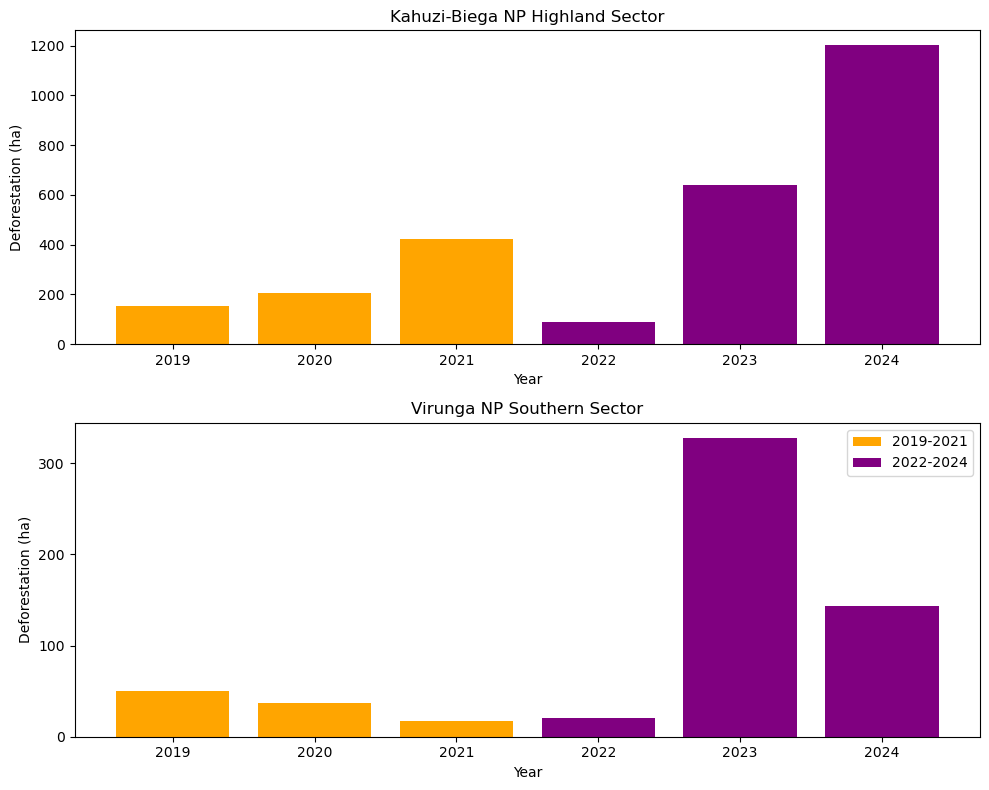

In [24]:
import matplotlib.pyplot as plt
# import pandas as pd

# Aggregate the deforestation alerts into annual buckets
df_aoi_pnkb['Year'] = df_aoi_pnkb['Month'].dt.year
df_aoi_pnvi['Year'] = df_aoi_pnvi['Month'].dt.year

annual_deforestation_pnkb = df_aoi_pnkb.groupby('Year')[['Deforestation_HA', 'Deforestation_SQKM']].sum().reset_index()
annual_deforestation_pnvi = df_aoi_pnvi.groupby('Year')[['Deforestation_HA', 'Deforestation_SQKM']].sum().reset_index()

years = np.arange(2019, 2025)  # Ensure 2024 is included

# Define the periods and colors
periods = [(2019, 2021), (2022, 2024)]
colors = ['orange', 'purple']

# Create a figure with subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

# Define the bar width and index
bar_width = 0.35
index = np.arange(len(years)) #annual_deforestation_pnkb['Year']))

# Plot for the first AOI
ax1 = axes[0]
# bars1 = ax1.bar(index, annual_deforestation_pnkb['Deforestation_HA'], bar_width, color=['blue'], label='PNKB')
for period, color in zip(periods, colors):
    mask = (annual_deforestation_pnkb['Year'] >= period[0]) & (annual_deforestation_pnkb['Year'] <= period[1])
    ax1.bar(annual_deforestation_pnkb[mask]['Year'], annual_deforestation_pnkb[mask]['Deforestation_HA'], color=color, label=f'{period[0]}-{period[1]}')
ax1.set_xticks(years)  # Ensure 2024 remains on X-axis
ax1.set_yticks(np.arange(0, annual_deforestation_pnkb["Deforestation_HA"].max() + 50, 200))  # Ensure 2024 remains on X-axis
# ax1.set_yticks(np.arange(0, 15, 5))  # Ensure 2024 remains on X-axis
ax1.set_xlabel('Year')
ax1.set_ylabel('Deforestation (ha)')
# ax1.set_ylabel('Deforestation (km²)')
# ax1.set_title(f'Deforestation in {aoi_names[0]}')
ax1.set_title(f'Kahuzi-Biega NP Highland Sector')
# ax1.legend()

# Plot for the second AOI
ax2 = axes[1]
# bars2 = ax2.bar(index, list(annual_deforestation_pnvi.values()), bar_width, color=['blue', 'green', 'red'], label='PNVi_Area_A')
for period, color in zip(periods, colors):
    mask = (annual_deforestation_pnvi['Year'] >= period[0]) & (annual_deforestation_pnvi['Year'] <= period[1])
    ax2.bar(annual_deforestation_pnvi[mask]['Year'], annual_deforestation_pnvi[mask]['Deforestation_HA'], color=color, label=f'{period[0]}-{period[1]}')
ax2.set_xticks(years)  # Ensure 2024 remains on X-axis
ax2.set_yticks(np.arange(0, annual_deforestation_pnvi["Deforestation_HA"].max() + 50, 100))  # Ensure 2024 remains on X-axis
ax2.set_xlabel('Year')
ax2.set_ylabel('Deforestation (ha)') #@ (km²)
ax2.set_title(f'Virunga NP Southern Sector')
# ax2.set_title(f'Deforestation in {aoi_names[1]}')
ax2.legend()

# Add labels for each bar
# for i, bar in enumerate(bars1):
#     height = bar.get_height()
#     period = list(annual_deforestation_pnkb.keys())[i]
#     start_year, end_year = map(int, period.split('-'))
#     num_years = end_year - start_year + 1
#     annual_rate = height / num_years
#     ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f} ha\n{annual_rate:.2f} ha/yr', ha='center', va='bottom', fontsize=8, color='black')

# for i, bar in enumerate(bars2):
#     height = bar.get_height()
#     period = list(summary_pnvi.keys())[i]
#     start_year, end_year = map(int, period.split('-'))
#     num_years = end_year - start_year + 1
#     annual_rate = height / num_years
#     ax2.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f} ha\n{annual_rate:.2f} ha/yr', ha='center', va='bottom', fontsize=8, color='black')


# # Plot for both AOIs
# plot_deforestation(axes[0], annual_deforestation_pnkb, aoi_names[1])
# plot_deforestation(axes[1], annual_deforestation_pnvi, aoi_names[0])

# Adjust layout
plt.tight_layout()
plt.show()

In [25]:
annual_deforestation_pnkb
annual_deforestation_pnkb.to_csv(os.path.join(output_path, 'gfw_annual_deforestation_pnkb.csv'), index=False)

In [26]:
annual_deforestation_pnvi
annual_deforestation_pnvi.to_csv(os.path.join(output_path, 'gfw_annual_deforestation_pnvi.csv'), index=False)

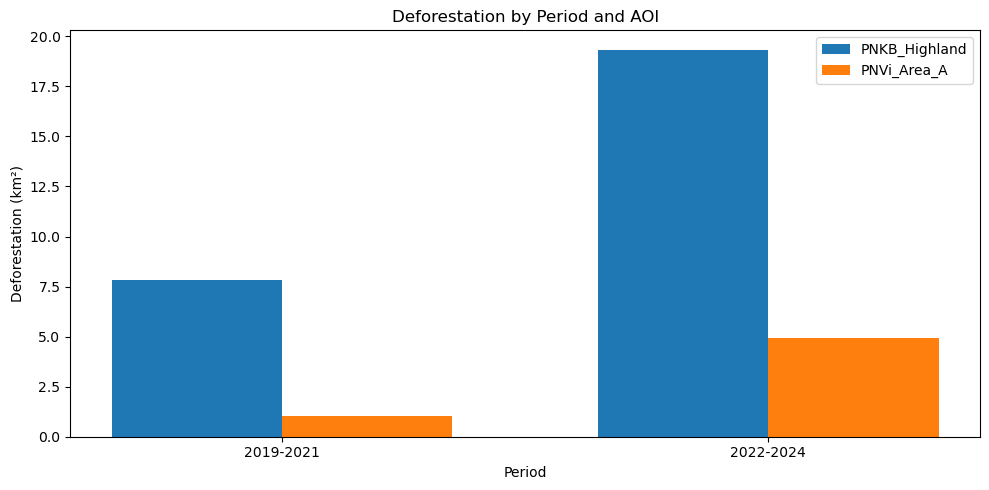

In [25]:
import matplotlib.pyplot as plt

# Define the periods
periods = [(2019, 2021), (2022, 2024)]

# Initialize dictionaries to hold the summary data
summary_pnkb = {}
summary_pnvi = {}

# Calculate the summary for PNKB_Highland
for period in periods:
    start_year, end_year = period
    mask = (annual_deforestation_pnkb['Year'] >= start_year) & (annual_deforestation_pnkb['Year'] <= end_year)
    total_deforestation = annual_deforestation_pnkb[mask]['Deforestation_SQKM'].sum()
    summary_pnkb[f'{start_year}-{end_year}'] = total_deforestation

# Calculate the summary for PNVi_Area_A
for period in periods:
    start_year, end_year = period
    mask = (annual_deforestation_pnvi['Year'] >= start_year) & (annual_deforestation_pnvi['Year'] <= end_year)
    total_deforestation = annual_deforestation_pnvi[mask]['Deforestation_SQKM'].sum()
    summary_pnvi[f'{start_year}-{end_year}'] = total_deforestation

# Create a figure with subplots
fig, ax = plt.subplots(figsize=(10, 5))

# Define the bar width and index
bar_width = 0.35
index = np.arange(len(periods))

# Plot the deforestation for PNKB_Highland
ax.bar(index, list(summary_pnkb.values()), bar_width, label='PNKB_Highland')

# Plot the deforestation for PNVi_Area_A
ax.bar(index + bar_width, list(summary_pnvi.values()), bar_width, label='PNVi_Area_A')

# Add labels, title, and legend
ax.set_xlabel('Period')
ax.set_ylabel('Deforestation (km²)')
ax.set_title('Deforestation by Period and AOI')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels([f'{start_year}-{end_year}' for start_year, end_year in periods])
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [26]:
# Define the periods
periods = [(2019, 2021), (2022, 2024)]

# Initialize dictionaries to hold the summary data
summary_pnkb = {}
summary_pnvi = {}

# Calculate the summary for PNKB_Highland
for period in periods:
    start_year, end_year = period
    mask = (annual_deforestation_pnkb['Year'] >= start_year) & (annual_deforestation_pnkb['Year'] <= end_year)
    total_deforestation = annual_deforestation_pnkb[mask]['Deforestation_HA'].sum()
    summary_pnkb[f'{start_year}-{end_year}'] = total_deforestation

# Calculate the summary for PNVi_Area_A
for period in periods:
    start_year, end_year = period
    mask = (annual_deforestation_pnvi['Year'] >= start_year) & (annual_deforestation_pnvi['Year'] <= end_year)
    total_deforestation = annual_deforestation_pnvi[mask]['Deforestation_HA'].sum()
    summary_pnvi[f'{start_year}-{end_year}'] = total_deforestation

# Print the summaries
print("Summary of deforestation in PNKB_Highland for designated periods:")
for period, total_deforestation in summary_pnkb.items():
    print(f"  {period}: {total_deforestation} hectares")

print("\nSummary of deforestation in PNVi_Area_A for designated periods:")
for period, total_deforestation in summary_pnvi.items():
    print(f"  {period}: {total_deforestation} hectares")

Summary of deforestation in PNKB_Highland for designated periods:
  2019-2021: 781.471745999994 hectares
  2022-2024: 1933.0540109996887 hectares

Summary of deforestation in PNVi_Area_A for designated periods:
  2019-2021: 105.29526600000003 hectares
  2022-2024: 491.8789619999974 hectares


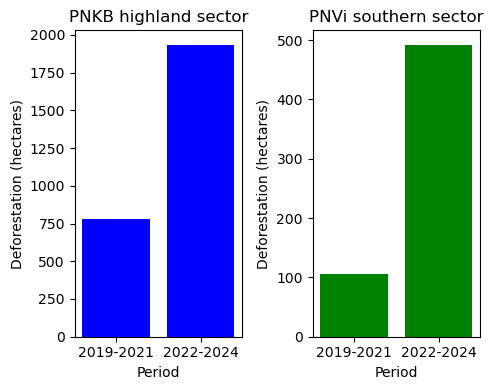

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Define the periods
periods = [(2019, 2021), (2022, 2024)]

# Initialize dictionaries to hold the summary data
summary_pnkb = {}
summary_pnvi = {}

# Calculate the summary for PNKB_Highland
for period in periods:
    start_year, end_year = period
    mask = (annual_deforestation_pnkb['Year'] >= start_year) & (annual_deforestation_pnkb['Year'] <= end_year)
    total_deforestation = annual_deforestation_pnkb[mask]['Deforestation_HA'].sum()
    summary_pnkb[f'{start_year}-{end_year}'] = total_deforestation

# Calculate the summary for PNVi_Area_A
for period in periods:
    start_year, end_year = period
    mask = (annual_deforestation_pnvi['Year'] >= start_year) & (annual_deforestation_pnvi['Year'] <= end_year)
    total_deforestation = annual_deforestation_pnvi[mask]['Deforestation_HA'].sum()
    summary_pnvi[f'{start_year}-{end_year}'] = total_deforestation

# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 4))

# Define the bar width and index
bar_width = 0.8
index = np.arange(len(periods))

# Plot the deforestation for PNKB_Highland
ax1 = axes[0]
ax1.bar(index, list(summary_pnkb.values()), bar_width, color=['blue'], label='PNKB_Highland')
ax1.set_xlabel('Period')
ax1.set_ylabel('Deforestation (hectares)')
ax1.set_title('PNKB highland sector')
ax1.set_xticks(index)
ax1.set_xticklabels([f'{start_year}-{end_year}' for start_year, end_year in periods])
# ax1.legend()

# Plot the deforestation for PNVi_Area_A
ax2 = axes[1]
ax2.bar(index, list(summary_pnvi.values()), bar_width, color=['green'], label='PNVi_Area_A')
ax2.set_xlabel('Period')
ax2.set_ylabel('Deforestation (hectares)')
ax2.set_title('PNVi southern sector')
ax2.set_xticks(index)
ax2.set_xticklabels([f'{start_year}-{end_year}' for start_year, end_year in periods])
# ax2.legend()

# Show the plot
plt.tight_layout()
plt.show()

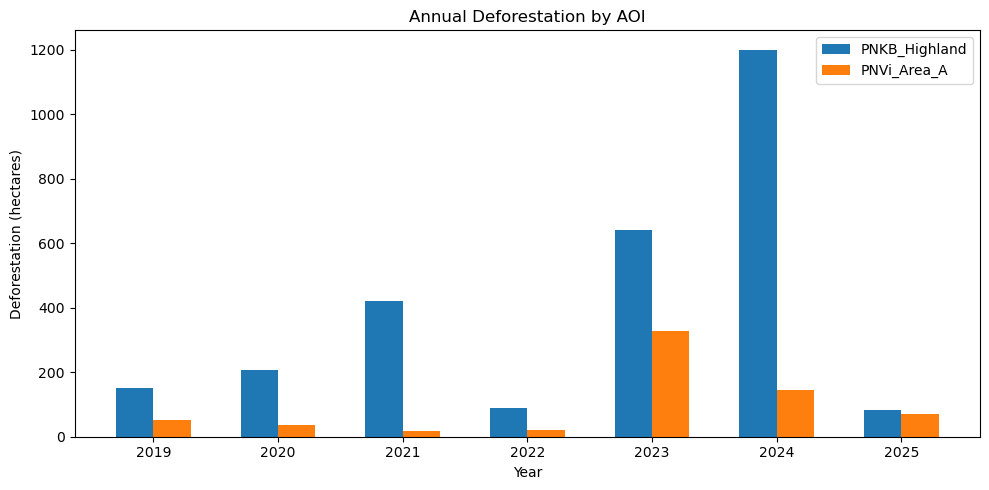

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with subplots
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the annual deforestation for both AOIs
bar_width = 0.3
index = np.arange(len(annual_deforestation_pnkb))

bar1 = ax.bar(index, annual_deforestation_pnkb['Deforestation_HA'], bar_width, label='PNKB_Highland')
bar2 = ax.bar(index + bar_width, annual_deforestation_pnvi['Deforestation_HA'], bar_width, label='PNVi_Area_A')

# Add labels, title, and legend
ax.set_xlabel('Year')
ax.set_ylabel('Deforestation (hectares)')
ax.set_title('Annual Deforestation by AOI')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(annual_deforestation_pnkb['Year'])
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

### Create rolling average of deforestation

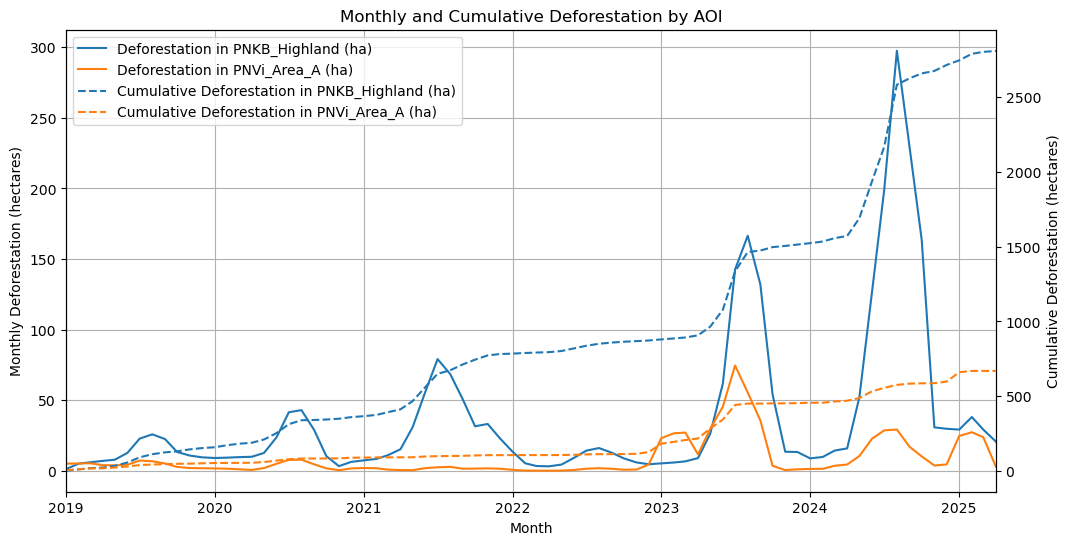

In [27]:
import matplotlib.pyplot as plt

df_aoi_pnkb['Rolling_HA'] = df_aoi_pnkb['Deforestation_HA'].rolling(window=3, min_periods=1).mean()
df_aoi_pnvi['Rolling_HA'] = df_aoi_pnvi['Deforestation_HA'].rolling(window=3, min_periods=1).mean()

# Find the common date range
min_date = max(df_aoi_pnkb['Month'].min(), df_aoi_pnvi['Month'].min())
max_date = min(df_aoi_pnkb['Month'].max(), df_aoi_pnvi['Month'].max())

# Plot deforestation through time for both AOIs on the same plot with a secondary axis for cumulative stats
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot monthly deforestation using a rolling average of 3 months
ax1.plot(df_aoi_pnkb['Month'], df_aoi_pnkb['Rolling_HA'], label=f'Deforestation in {aoi_names[0]} (ha)')
ax1.plot(df_aoi_pnvi['Month'], df_aoi_pnvi['Rolling_HA'], label=f'Deforestation in {aoi_names[1]} (ha)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Deforestation (hectares)')
# ax1.legend(loc='upper left')
ax1.grid(True)

# Set the x-axis limits to the common date range
ax1.set_xlim([min_date, max_date])

# Create a secondary y-axis for cumulative deforestation
ax2 = ax1.twinx()
ax2.plot(df_aoi_pnkb['Month'], df_aoi_pnkb['Cumulative_HA'], label=f'Cumulative Deforestation in {aoi_names[0]} (ha)', linestyle='--')
ax2.plot(df_aoi_pnvi['Month'], df_aoi_pnvi['Cumulative_HA'], label=f'Cumulative Deforestation in {aoi_names[1]} (ha)', linestyle='--')
ax2.set_ylabel('Cumulative Deforestation (hectares)')

# Get handles and labels from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine handles and labels
handles = handles1 + handles2
labels = labels1 + labels2

# Create a single legend
ax1.legend(handles, labels, loc='upper left')

plt.title('Monthly and Cumulative Deforestation by AOI')
plt.show()

Create graph of deforestation alerts

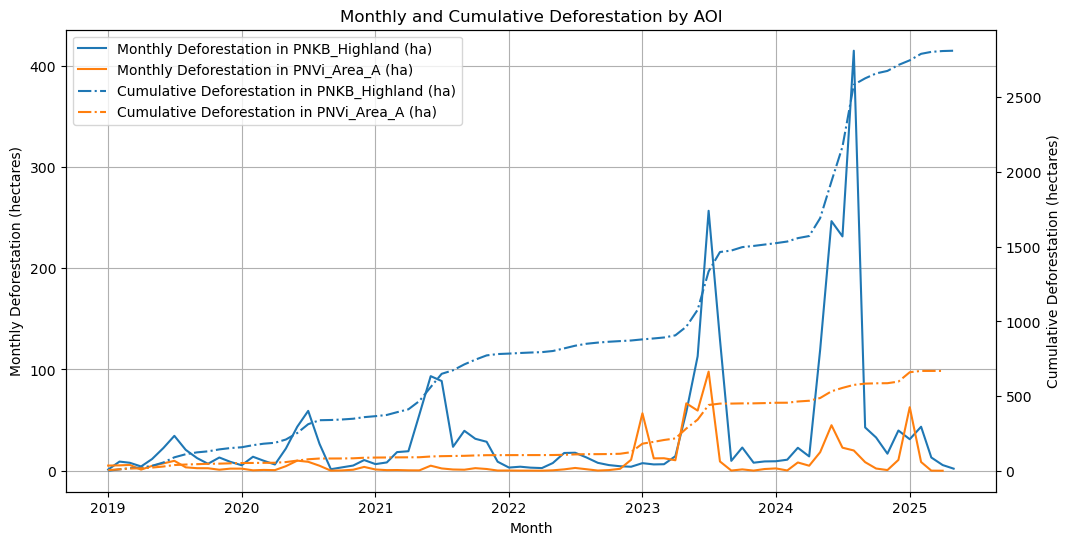

In [28]:
# Plot deforestation through time for both AOIs on the same plot with a secondary axis for cumulative stats
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot monthly deforestation
line1, = ax1.plot(df_aoi_pnkb['Month'], df_aoi_pnkb['Deforestation_HA'], label=f'Monthly Deforestation in {aoi_names[0]} (ha)')
line2, = ax1.plot(df_aoi_pnvi['Month'], df_aoi_pnvi['Deforestation_HA'], label=f'Monthly Deforestation in {aoi_names[1]} (ha)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Deforestation (hectares)')
ax1.grid(True)

# Create a secondary y-axis for cumulative deforestation
ax2 = ax1.twinx()
line5, = ax2.plot(df_aoi_pnkb['Month'], df_aoi_pnkb['Cumulative_HA'], label=f'Cumulative Deforestation in {aoi_names[0]} (ha)', linestyle='-.')
line6, = ax2.plot(df_aoi_pnvi['Month'], df_aoi_pnvi['Cumulative_HA'], label=f'Cumulative Deforestation in {aoi_names[1]} (ha)', linestyle='-.')
ax2.set_ylabel('Cumulative Deforestation (hectares)')

# Create legends
lines_1 = [line1, line2] #, line3, line4]
labels_1 = [line.get_label() for line in lines_1]
legend_1 = ax1.legend(lines_1, labels_1, loc='upper left')

lines_2 = [line5, line6]
labels_2 = [line.get_label() for line in lines_2]
legend_2 = ax1.legend(lines_2, labels_2, loc='upper left', bbox_to_anchor=(0, 0.90))

# Add the first legend back to the plot
# ax1.add_artist(legend_1)

# Get handles and labels from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine handles and labels
handles = handles1 + handles2
labels = labels1 + labels2

# Create a single legend
ax1.legend(handles, labels, loc='upper left')

plt.title('Monthly and Cumulative Deforestation by AOI')
plt.show()

Trying this as a bar chart instead.

C:\Users\Carol\AppData\Local\Temp\ipykernel_8616\2610563876.py:21: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  legend_1 = ax1.legend(bars, labels_1, loc='upper left')


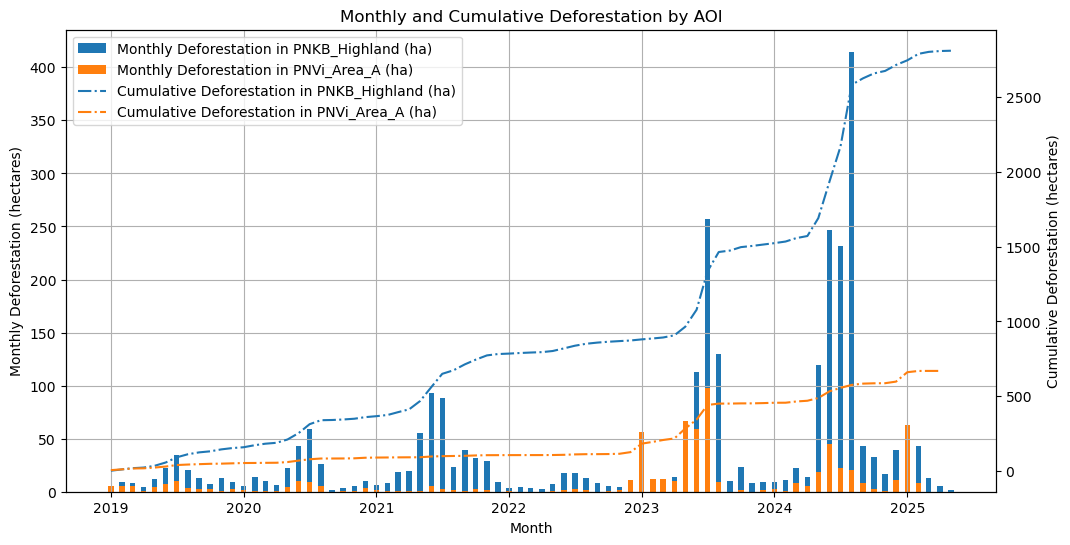

In [29]:
# Plot deforestation through time for both AOIs on the same plot with a secondary axis for cumulative stats
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot monthly deforestation
bar_width = 15  # Width of the bars in days
ax1.bar(df_aoi_pnkb['Month'], df_aoi_pnkb['Deforestation_HA'], width=bar_width, label=f'Monthly Deforestation in {aoi_names[0]} (ha)', align='center')
ax1.bar(df_aoi_pnvi['Month'], df_aoi_pnvi['Deforestation_HA'], width=bar_width, label=f'Monthly Deforestation in {aoi_names[1]} (ha)', align='center')
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Deforestation (hectares)')
ax1.grid(True)

# Create a secondary y-axis for cumulative deforestation
ax2 = ax1.twinx()
line5, = ax2.plot(df_aoi_pnkb['Month'], df_aoi_pnkb['Cumulative_HA'], label=f'Cumulative Deforestation in {aoi_names[0]} (ha)', linestyle='-.')
line6, = ax2.plot(df_aoi_pnvi['Month'], df_aoi_pnvi['Cumulative_HA'], label=f'Cumulative Deforestation in {aoi_names[1]} (ha)', linestyle='-.')
ax2.set_ylabel('Cumulative Deforestation (hectares)')

# Create legends
bars = [ax1.patches[0], ax1.patches[1]]
labels_1 = [bar.get_label() for bar in bars]
legend_1 = ax1.legend(bars, labels_1, loc='upper left')

lines_2 = [line5, line6]
labels_2 = [line.get_label() for line in lines_2]
legend_2 = ax1.legend(lines_2, labels_2, loc='upper left', bbox_to_anchor=(0, 0.90))

# Add the first legend back to the plot
# ax1.add_artist(legend_1)

# Get handles and labels from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine handles and labels
handles = handles1 + handles2
labels = labels1 + labels2

# Create a single legend
ax1.legend(handles, labels, loc='upper left')

plt.title('Monthly and Cumulative Deforestation by AOI')
plt.show()

Making individual plots for each AOI

C:\Users\Carol\AppData\Local\Temp\ipykernel_8616\4057506704.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  vector_features['AOI_Area_sqkm'] = vector_features['geometry'].area / 1_000_000  # Convert area to sqkm


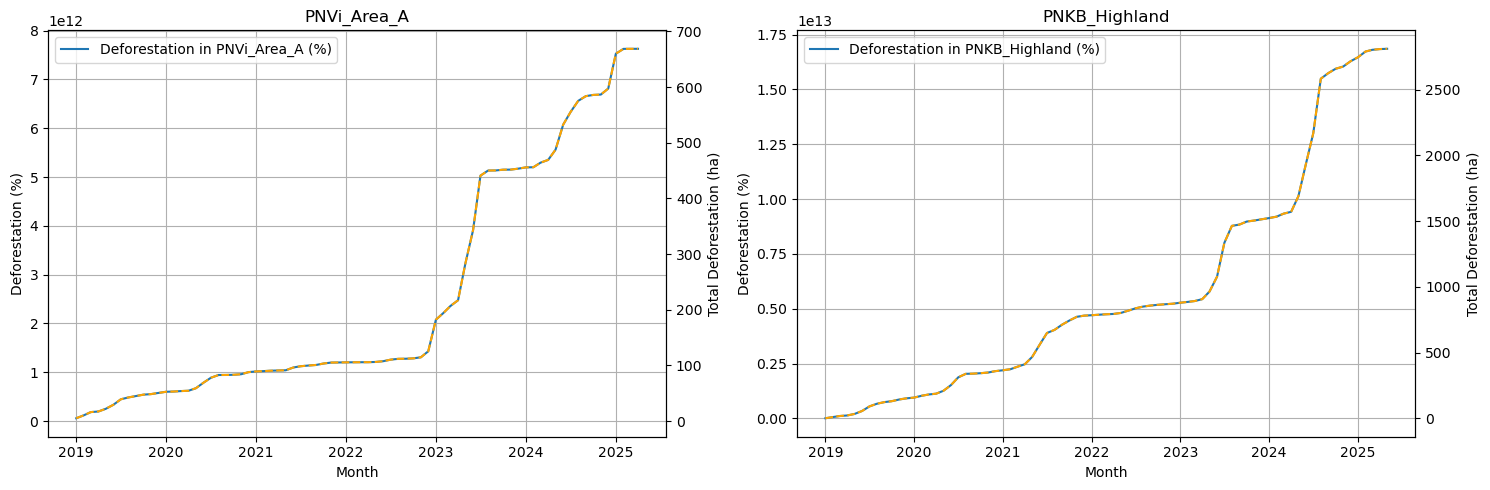

In [30]:
# import matplotlib.pyplot as plt

# Calculate the deforestation as a percentage of the AOI's area
vector_features['AOI_Area_sqkm'] = vector_features['geometry'].area / 1_000_000  # Convert area to sqkm

# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=len(vector_features), figsize=(15, 5))

# Loop over each AOI feature and create a subplot
for idx, aoi in vector_features.iterrows():
    aoi_name = aoi['aoi_name']
    aoi_area_sqkm = aoi['AOI_Area_sqkm']
    
    # Calculate the deforestation percentage
    df_aoi = df_aoi_pnkb if aoi_name == aoi_names[0] else df_aoi_pnvi
    df_aoi['Deforestation_Percentage'] = (df_aoi['Cumulative_HA'] / aoi_area_sqkm) * 100
    
    # Create a subplot for the current AOI
    ax1 = axes[idx]
    ax1.plot(df_aoi['Month'], df_aoi['Deforestation_Percentage'], label=f'Deforestation in {aoi_name} (%)')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Deforestation (%)')
    ax1.set_title(f'{aoi_name}')
    ax1.grid(True)
    
    # Create a secondary y-axis for the total quantity of deforestation
    ax2 = ax1.twinx()
    ax2.plot(df_aoi['Month'], df_aoi['Cumulative_HA'], label=f'Cumulative Deforestation in {aoi_name} (ha)', linestyle='--', color='orange')
    ax2.set_ylabel('Total Deforestation (ha)') #, color='orange')
    
    # combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    ax1.legend(loc='upper left')

# Adjust layout
plt.tight_layout()
plt.show()

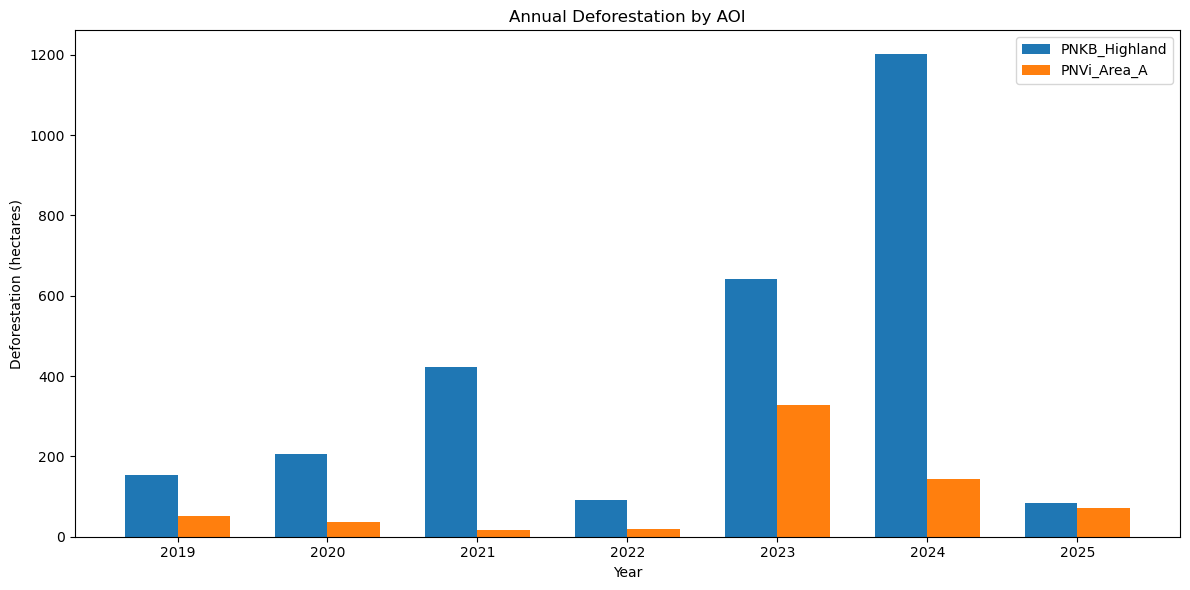

In [33]:
import matplotlib.pyplot as plt

# Create a figure with subplots
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the annual deforestation for both AOIs
bar_width = 0.35
index = np.arange(len(annual_deforestation_pnkb))

bar1 = ax.bar(index, annual_deforestation_pnkb['Deforestation_HA'], bar_width, label='PNKB_Highland')
bar2 = ax.bar(index + bar_width, annual_deforestation_pnvi['Deforestation_HA'], bar_width, label='PNVi_Area_A')

# Add labels, title, and legend
ax.set_xlabel('Year')
ax.set_ylabel('Deforestation (hectares)')
ax.set_title('Annual Deforestation by AOI')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(annual_deforestation_pnkb['Year'])
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
selected_aoi_names

In [ ]:
vector_features

In [ ]:
# Define the paths to the raster and vector files
global_forest_cover = r"C:\Users\Carol\Dropbox\GIS\Projects\IOB_AlbertineRift\2_intermediate_data\raster\Hansen_GFC-2023-v1.11_lossyear_clipped.tif"

check_path(global_forest_cover)

In [ ]:
geoms = [geom for geom in vector_features['geometry']] #.tolist()
geoms

In [ ]:
print(type(out_transform), type(out_image))


In [ ]:

# Open the raster file
with rasterio.open(global_forest_cover) as src:
    # Initialize a variable to hold the total deforestation area
    total_deforestation_area = 0
    
    for geom in geoms:
        # Mask the raster data with the current vector feature
        out_image, out_transform = mask(src, geoms, crop=True)
        
        # Get the data array from the masked raster
        data = out_image[0]
        
        # Calculate the deforestation area (10m x 10m pixels)
        # deforestation_area = np.sum(data > 0) * 10 * 10  # Sum of non-zero pixels times pixel area
        deforestation_area = np.sum((data >= 1) & (data <= 23)) * 100  # 10m x 10m = 100m²

        # Add the deforestation area to the total
        total_deforestation_area += deforestation_area

print(f"Total deforestation area within the vector features: {total_deforestation_area} square meters")

In [ ]:

global_forest_cover_by_aoi = {}

# Define the periods and colors
periods = [(2000, 2018), (2019, 2021), (2022, 2023)]
colors = ['blue', 'green', 'red']

# Open the raster file
with rasterio.open(global_forest_cover) as src:
    # geom = [df_aoi['geometry'].iloc[0]]

    # print(f'Processing AOI: {aoi_name}')

    # Loop over each AOI feature
    for idx, aoi in vector_features.iterrows():
        geom = [aoi['geometry']]
        aoi_name = aoi['aoi_name']
        # aoi_area_ha = aoi['AOI_Area_sqkm']

        print(f"Processing AOI: {aoi_name}")

        # Mask the raster data with the current AOI
        out_image, out_transform = mask(src, geom, crop=True)
        data = out_image[0]

        # Create a list to hold the deforestation data
        deforestation_years = []

        # Loop over each pixel in the masked data array
        for y in range(data.shape[0]):
            for x in range(data.shape[1]):
                # Get the deforestation year from the pixel value
                year = data[y, x]
                
                # If the year is 0, skip to the next pixel (no deforestation)
                if year == 0:
                    continue
                
                # Convert the pixel value to the actual year
                deforestation_year = 2000 + year - 1
                
                # Add the deforestation year to the list
                deforestation_years.append(deforestation_year)

        # Convert the deforestation years to a DataFrame
        df_deforestation = pd.DataFrame(deforestation_years, columns=['Year'])

        # Aggregate the deforestation data into the specified periods
        df_deforestation['Period'] = pd.cut(df_deforestation['Year'], bins=[1999, 2018, 2021, 2023], labels=['2000-2018', '2019-2021', '2022-2023'])
        annual_deforestation = df_deforestation['Period'].value_counts().sort_index()

        # Create a bar plot for the current AOI
        fig, ax = plt.subplots(figsize=(8, 6))
        for period, color in zip(periods, colors):
            period_label = f'{period[0]}-{period[1]}'
            if period_label in annual_deforestation.index:
                ax.bar(period_label, annual_deforestation[period_label], color=color, label=period_label)
        ax.set_xlabel('Period')
        ax.set_ylabel('Deforestation (number of pixels)')
        ax.set_title(f'Deforestation in {aoi_name}')
        ax.legend()

        # Show the plot
        plt.show()

# Loop over each AOI feature and process it
for idx, aoi in vector_features.iterrows():
    aoi_geom = aoi['geometry']
    aoi_name = aoi['aoi_name']  # Replace with the actual field name for AOI name
    # process_aoi(aoi_geom, aoi_name)

In [ ]:
# Create a list to hold the output data
output = []

In [ ]:
# Loop over each pixel in the data array
for y in range(height):
    for x in range(width):
        # Get the alert value from the data array
        alert = data[y,x]
        
        # If the alert value is 0, skip to the next pixel
        if alert == 0:
            continue
        
        # Determine the confidence level and number of days since Dec 31, 2014
        conf = int(str(alert)[0])
        days = int(str(alert)[1:])
        date = np.datetime64('2014-12-31') + np.timedelta64(days, 'D')
        
        # Convert the pixel coordinates to longitude and latitude
        lon, lat = rasterio.transform.xy(transform, y, x)
        
        # Add the data to the output list
        output.append([alert, lon, lat, date, conf])

In [ ]:
# Write the output list to a CSV file
with open('GFW_alerts_parsed.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Alert','Longitude', 'Latitude', 'Date', 'Confidence'])
    writer.writerows(output)

In [ ]:
with rasterio.open(raster_path) as src:
    # Create a window from the bbox
    window = from_bounds(*bbox, transform=src.transform)
    data = src.read(1, window=window)

    # Initialize a dictionary to hold the deforestation area for each AOI
    deforestation_by_aoi = {}

    # Loop over each vector feature
    for idx, feature in vector_features.iterrows():
        geom = [feature['geometry']]
        aoi_name = feature['aoi_name']  # Replace with the actual field name for AOI name
        
        # Mask the raster data with the current vector feature
        out_image, out_transform = mask(src, geom, crop=True)
        
        # Get the data array from the masked raster
        data = out_image[0]
        
        # Initialize a variable to hold the deforestation area for the current AOI
        deforestation_area_sqm = 0

        # Loop over each pixel in the data array
        for y in range(data.shape[0]):
            for x in range(data.shape[1]):
                # Get the alert value from the data array
                alert = data[y, x]
                
                # If the alert value is 0, skip to the next pixel
                if alert == 0:
                    continue

                # Determine the confidence level
                conf = int(str(alert)[0])
                
                # Only process alert levels 3 or 4
                if conf not in [3, 4]:
                # if conf not in [4]:
                    continue
                
                # Calculate the deforestation area (10m x 10m pixels)
                deforestation_area_sqm += 10 * 10  # Pixel area in square meters
        
        # Calculate the deforestation area (10m x 10m pixels)
        # deforestation_area_sqm = np.sum(data > 0) * 10 * 10  # Sum of non-zero pixels times pixel area

         # Convert to hectares and square kilometers
        deforestation_area_ha = deforestation_area_sqm / 10_000  # 1 hectare = 10,000 square meters
        deforestation_area_sqkm = deforestation_area_sqm / 1_000_000  # 1 square kilometer = 1,000,000 square meters
        
        # Add the deforestation area to the dictionary
        if aoi_name in deforestation_by_aoi:
            deforestation_by_aoi[aoi_name]['sqm'] += deforestation_area
            deforestation_by_aoi[aoi_name]['ha'] += deforestation_area_ha
            deforestation_by_aoi[aoi_name]['sqkm'] += deforestation_area_sqkm
        else:
            deforestation_by_aoi[aoi_name] = {
                'sqm': deforestation_area_sqm,
                'ha': deforestation_area_ha,
                'sqkm': deforestation_area_sqkm
            }

# Print the deforestation area for each AOI
for aoi_name, areas in deforestation_by_aoi.items():
    print(f"Total deforestation area in {aoi_name}:")
    print(f"  {areas['sqm']} square meters")
    print(f"  {areas['ha']} hectares")
    print(f"  {areas['sqkm']} square kilometers")